# Preparation

In [ ]:
!pip install pandas
!pip install matplotlib

# Import libraries
import pandas as pd

from Utils import *
%matplotlib inline

### Global Parameters

In [21]:
# Specify the data path
datafile = '../../../build/1.csv'

output_keys = ['Key','Benchmark', 'Label', 'Distribution', 'MatchingRate', 'Multiplicity', \
                'Occupancy', 'GPU Time (sec)', 'Elem/s (elem/sec)', 'TileSize']

### Import Data

In [22]:
# Read csv file
rawdf = pd.read_csv(datafile)

# Filter out skipped tests
perfdf = rawdf[rawdf["Key"] == rawdf["Value"]].reset_index(drop=True)


# Add labels
perfdf['Label'] = perfdf["Key"]
perfdf.loc[perfdf['Distribution'].notnull(), 'Label'] += "_" + perfdf['Distribution']
perfdf['Label'] += '_TILE'+perfdf["TileSize"].astype(str)

# Trim data frame for visualization
perfdf = perfdf[output_keys]

# Visualization

### Visualization Parameters

In [23]:
# Get benchmark list
unique_bms = perfdf["Benchmark"].unique()
for it in unique_bms:
    print(it)

static_map_insert_uniform_multiplicity
static_map_insert_unique_occupancy
static_map_insert_gaussian_skew
static_map_find_unique_occupancy
static_map_find_unique_matching_rate
static_map_contains_unique_occupancy
static_map_contains_unique_matching_rate
static_map_erase_unique_occupancy
static_map_erase_unique_matching_rate


### `insert` performance by varying key muliplicities
<ul>
<li>100'000'000 insertions</li>
<li>UNIFORM distribution</li>
</ul>

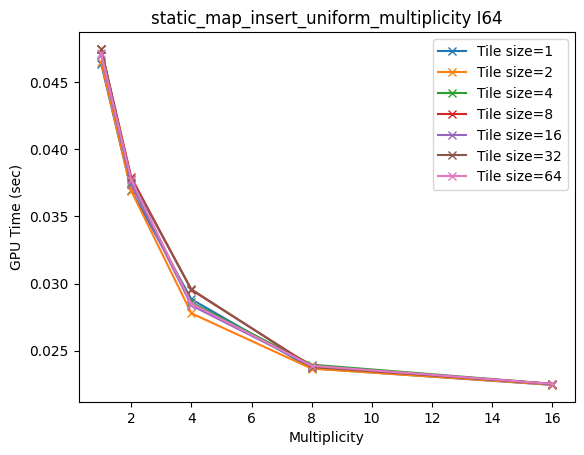

In [25]:
for bm in unique_bms:
    flag = "static_map_insert_uniform_multiplicity" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("TileSize")

        for group_name, group_data in groups:
          plt.plot(group_data["Multiplicity"], group_data["GPU Time (sec)"], label="Tile size="+str(group_name), marker="x")

          plt.title("static_map_insert_uniform_multiplicity I64")
          plt.xlabel("Multiplicity")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `insert` performance by varying occupancies
<ul>
<li>100'000'000 insertions</li>
<li>Fixed occupancy rate: 0.5</li>
</ul>

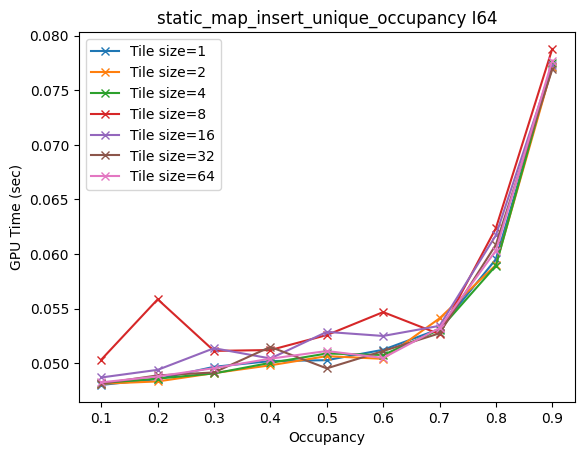

In [28]:
for bm in unique_bms:
    flag = "static_map_insert_unique_occupancy" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("TileSize")

        for group_name, group_data in groups:
          plt.plot(group_data["Occupancy"], group_data["GPU Time (sec)"], label="Tile size="+str(group_name), marker="x")

          plt.title("static_map_insert_unique_occupancy I64")
          plt.xlabel("Occupancy")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `find` performance by varying key muliplicities
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>Fixed occupancy: 0.5</li>
</ul>

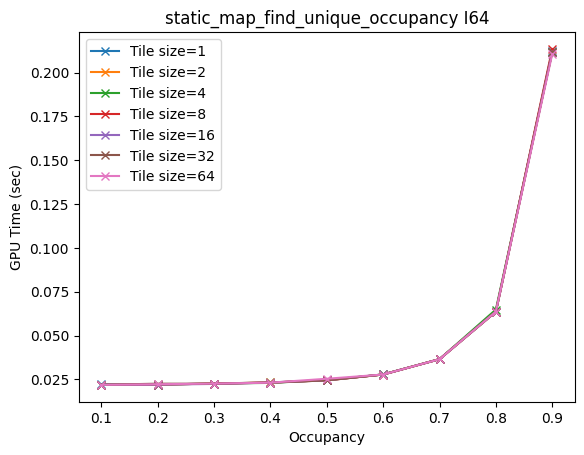

In [27]:
for bm in unique_bms:
    flag = "static_map_find_unique_occupancy" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("TileSize")

        for group_name, group_data in groups:
          plt.plot(group_data["Occupancy"], group_data["GPU Time (sec)"], label="Tile size="+str(group_name), marker="x")

          plt.title("static_map_find_unique_occupancy I64")
          plt.xlabel("Occupancy")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `contains` performance by varying occupancies
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>Fixed matching rate: 0.5</li>
<li>Fixed occupancy: 0.5</li>
</ul>

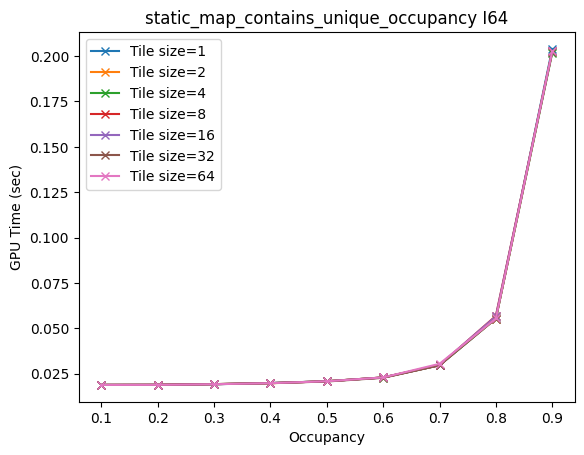

In [29]:
for bm in unique_bms:
    flag = "static_map_contains_unique_occupancy" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("TileSize")

        for group_name, group_data in groups:
          plt.plot(group_data["Occupancy"], group_data["GPU Time (sec)"], label="Tile size="+str(group_name), marker="x")

          plt.title("static_map_contains_unique_occupancy I64")
          plt.xlabel("Occupancy")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `find` performance by varying matching rates
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>Fixed occupancy: 0.5</li>
<li>Fixed matching rate: 0.5</li>
</ul>

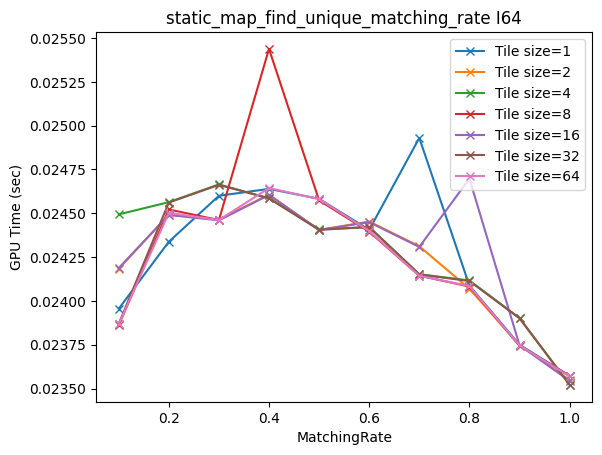

In [30]:
for bm in unique_bms:
    flag = "static_map_find_unique_matching_rate" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("TileSize")

        for group_name, group_data in groups:
          plt.plot(group_data["MatchingRate"], group_data["GPU Time (sec)"], label="Tile size="+str(group_name), marker="x")

          plt.title("static_map_find_unique_matching_rate I64")
          plt.xlabel("MatchingRate")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `erase` performance by varying key muliplicities
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>Fixed occupancy: 0.5</li>
</ul>

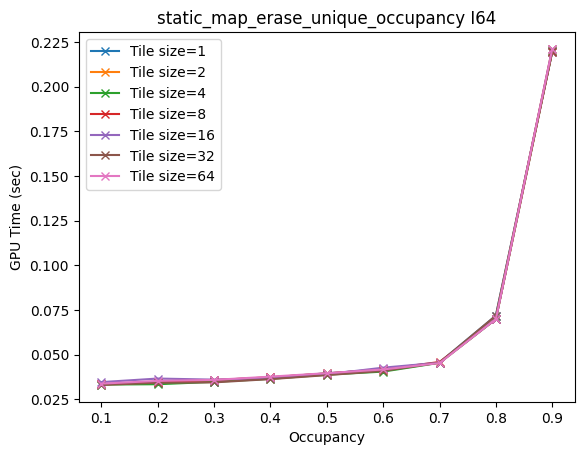

In [31]:
for bm in unique_bms:
    flag = "static_map_erase_unique_occupancy" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("TileSize")

        for group_name, group_data in groups:
          plt.plot(group_data["Occupancy"], group_data["GPU Time (sec)"], label="Tile size="+str(group_name), marker="x")

          plt.title("static_map_erase_unique_occupancy I64")
          plt.xlabel("Occupancy")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `contains` performance by varying matching rates
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>Fixed occupancy: 0.5</li>
</ul>

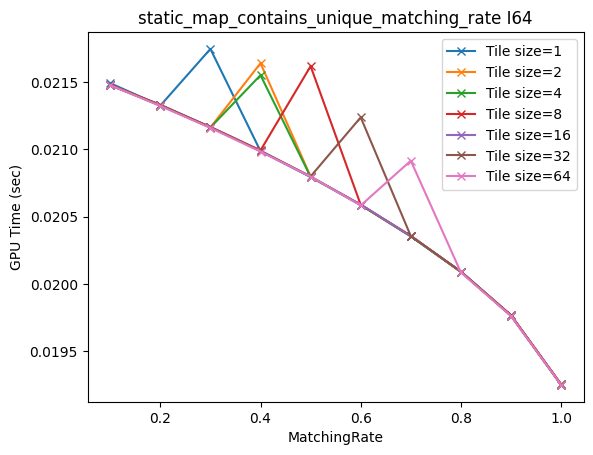

In [32]:
for bm in unique_bms:
    flag = "static_map_contains_unique_matching_rate" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("TileSize")

        for group_name, group_data in groups:
          plt.plot(group_data["MatchingRate"], group_data["GPU Time (sec)"], label="Tile size="+str(group_name), marker="x")

          plt.title("static_map_contains_unique_matching_rate I64")
          plt.xlabel("MatchingRate")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `erase` performance by varying matching rates
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>Fixed matching rate: 0.5</li>
</ul>

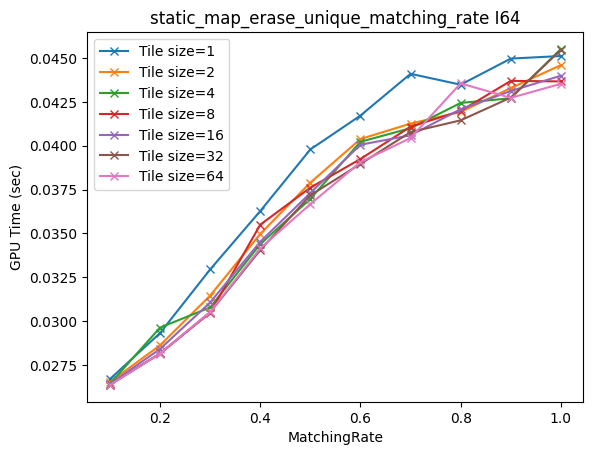

In [33]:
for bm in unique_bms:
    flag = "static_map_erase_unique_matching_rate" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("TileSize")

        for group_name, group_data in groups:
          plt.plot(group_data["MatchingRate"], group_data["GPU Time (sec)"], label="Tile size="+str(group_name), marker="x")

          plt.title("static_map_erase_unique_matching_rate I64")
          plt.xlabel("MatchingRate")
          plt.ylabel("GPU Time (sec)")
          plt.legend()